# Cold Start: Whose Baseline, and How Much?
### Baseline transfer and minimum viable baseline window

The mechanism finding says the discriminative signal is deviation from a personal baseline. That
creates a deployment problem this project has not yet addressed: **a new user has no baseline.**
Existing results make it concrete — naive chronological calibration yielded +0.001, because the
opening minutes of a session contain no stress examples.

Two questions follow, and this notebook answers both.

```
  Experiment 1 - WHOSE baseline?
     Can a new user borrow a baseline from physiologically
     similar users until they have their own?

  Experiment 2 - HOW MUCH data?
     How many minutes of a user's own recording are needed
     before the baseline is stable enough to trust?
```

---

## An honest correction built into the design

A borrowed baseline is not a zero-data solution. Assigning a new user to a donor group requires
*some* of their data — enough to characterise their resting physiology. The comparison is therefore
not "borrowed versus own" but a ladder:

| Condition | Data needed from the new user | What it represents |
|---|---|---|
| Population baseline | none | the crudest fallback |
| Borrowed (cluster) baseline | ~2 minutes, to assign a cluster | the proposed protocol |
| Own baseline, N minutes | N minutes | the current approach |
| Own baseline, full session | whole recording | the offline ideal |

The useful question is where the borrowed baseline sits on that ladder, and at what point a user's
own data overtakes it.

---

## Both outcomes are reportable

```
  Baselines transfer      -> a cold-start protocol other work
                             can adopt

  Baselines do not        -> quantitative evidence that the
  transfer                   baseline is irreducibly personal,
                             which strengthens the existing
                             personalisation argument
```

## Leakage controls

Cluster definitions are fitted on training subjects only, donors exclude the held-out subject, and
baseline windows never overlap the evaluation windows. Each is asserted in code rather than assumed.


## 1. Setup

In [1]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 16.6 MB/s eta 0:00:00


In [2]:
import os, pickle, warnings, json, time
import numpy as np, pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import welch
from scipy.stats import wilcoxon
try:
    from scipy.integrate import trapezoid as TRAPZ
except ImportError:
    from scipy.integrate import trapz as TRAPZ
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import f1_score, cohen_kappa_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import neurokit2 as nk
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42)

DATA_PATH='/kaggle/input/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/WESAD'
SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
SUBJECT_IDS=[2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]
CLASS_NAMES=['relaxed','mild','moderate','high']; NCLS=4
WINDOW=120; STEP=5
RESULTS=f'{SAVE}/coldstart.json'
BEATS_PER_MIN=80.0          # approximate, for converting beats to minutes
print("ready")

ready


## 2. Data preparation

In [3]:
def load_subject(sid):
    with open(f"{DATA_PATH}/S{sid}/S{sid}.pkl",'rb') as f: d=pickle.load(f,encoding='latin1')
    return d['signal']['chest'], d['signal']['wrist']['TEMP'].flatten(), d['label'].flatten()
def extract_rr(ecg,fs=700):
    ecg=nk.ecg_clean(ecg.flatten(),sampling_rate=fs); _,i=nk.ecg_peaks(ecg,sampling_rate=fs); rp=i['ECG_R_Peaks']
    return np.diff(rp)*(1000.0/fs),(rp[:-1]+rp[1:])/2.0/fs,rp
def clean_rr(rr,ts):
    rr=rr.copy().astype(float); rr[(rr<=300)|(rr>=2000)]=np.nan
    for i in range(1,len(rr)):
        if not np.isnan(rr[i-1]) and not np.isnan(rr[i]) and abs(rr[i]-rr[i-1])/rr[i-1]>0.20: rr[i]=np.nan
    m=np.isnan(rr)
    if m.any(): rr[m]=np.interp(np.where(m)[0],np.where(~m)[0],rr[~m])
    return rr,ts
def labels_to_rr(labels,rp):
    o=[]
    for i in range(len(rp)-1):
        seg=labels[rp[i]:rp[i+1]]; v=seg[seg>0]; o.append(0 if len(v)==0 else np.bincount(v).argmax())
    return np.array(o)

wesad={}
for sid in SUBJECT_IDS:
    try:
        chest,wt,labels=load_subject(sid); ecg=chest['ECG'].flatten()
        rr,ts,rp=extract_rr(ecg); rr,ts=clean_rr(rr,ts)
        rl=labels_to_rr(labels,rp); keep=rl>0
        rrk,tsk,lk=rr[keep],ts[keep],rl[keep]
        new=np.zeros(len(lk),dtype=int); si=np.where(lk==2)[0]
        if len(si)>0:
            srr=rrk[si]; loc=[]
            for i in range(len(srr)):
                w=srr[max(0,i-15):i+15]; dd=np.diff(w); loc.append(np.sqrt(np.mean(dd**2)) if len(dd)>0 else 50)
            loc=np.array(loc); p33,p66=np.percentile(loc,33),np.percentile(loc,66)
            for i,idx in enumerate(si): new[idx]=(1 if loc[i]>=p66 else 2 if loc[i]>=p33 else 3)
        wesad[f'S{sid}']=dict(rr_ms=rrk,timestamps=tsk,labels=new)
    except Exception as e: print("FAIL",sid,e)
print(len(wesad),"subjects"); assert len(wesad)==15
for sid,d in wesad.items():
    mins=len(d['rr_ms'])/BEATS_PER_MIN
    print(f"  {sid}: {len(d['rr_ms']):5d} beats  ~{mins:.0f} min")

15 subjects
  S2:  3591 beats  ~45 min
  S3:  3177 beats  ~40 min
  S4:  3398 beats  ~42 min
  S5:  3695 beats  ~46 min
  S6:  3711 beats  ~46 min
  S7:  3626 beats  ~45 min
  S8:  3938 beats  ~49 min
  S9:  4106 beats  ~51 min
  S10:  4943 beats  ~62 min
  S11:  4689 beats  ~59 min
  S13:  4636 beats  ~58 min
  S14:  4689 beats  ~59 min
  S15:  4177 beats  ~52 min
  S16:  4482 beats  ~56 min
  S17:  4131 beats  ~52 min


In [4]:
def hrv_features(rr):
    dd=np.diff(rr); nn=len(rr)
    rmssd=np.sqrt(np.mean(dd**2)) if nn>1 else 0.0
    sdnn=np.std(rr); mean_rr=np.mean(rr)
    pnn50=np.mean(np.abs(dd)>50)*100 if nn>1 else 0.0
    cv=sdnn/(mean_rr+1e-8)
    try:
        fs=4.0; t=np.cumsum(rr)/1000.0
        ti=np.arange(t[0],t[-1],1/fs); ri=np.interp(ti,t,rr)
        f,pxx=welch(ri-np.mean(ri),fs=fs,nperseg=min(256,len(ri)))
        band=lambda lo,hi: TRAPZ(pxx[(f>=lo)&(f<hi)],f[(f>=lo)&(f<hi)]) if np.any((f>=lo)&(f<hi)) else 0.0
        vlf,lf,hf=band(0.003,0.04),band(0.04,0.15),band(0.15,0.4)
    except Exception: vlf=lf=hf=0.0
    tot=lf+hf+1e-8
    sd1=np.sqrt(0.5)*np.std(dd) if nn>1 else 0.0
    sd2=np.sqrt(max(2*sdnn**2-0.5*np.std(dd)**2,0)) if nn>1 else 0.0
    return np.array([mean_rr,sdnn,rmssd,pnn50,cv,vlf,lf,hf,lf/(hf+1e-8),lf/tot,sd1,sd2,sd1/(sd2+1e-8)])
def resid_features(r):
    dd=np.diff(r)
    return np.array([np.mean(r),np.std(r),np.max(np.abs(r)),
                     np.mean(np.abs(dd)) if len(dd)>0 else 0.0,
                     np.polyfit(np.arange(len(r)),r,1)[0]])
print("feature functions ready")

feature functions ready


## 3. Baseline definitions

A baseline here is a smooth expected trajectory. Four sources are compared, differing only in whose
data — and how much of it — produced them.

The Cosinor form is retained for the own-baseline conditions so the comparison is against the
project's existing method. For borrowed and population baselines, a level shift is the only
transferable quantity: a donor's *timing* is meaningless for a different person, but their typical
level and spread are not.

In [5]:
def cos_model(th,M,A,P): return M+A*np.cos((2*np.pi/24.0)*th+P)

def own_baseline(rr,ts,upto=None):
    """Cosinor fitted on the first `upto` beats, extrapolated across the session.

    A short fitting window makes the Cosinor parameters unidentifiable and the
    extrapolation can diverge wildly -- on a 2-minute budget an unclamped fit was
    observed to predict 34,000 ms, which is not a heartbeat. Such a baseline would
    corrupt the residuals rather than represent a genuine short-budget result, so
    implausible fits fall back to the prefix mean and are counted."""
    fit_rr = rr if upto is None else rr[:upto]
    fit_ts = ts if upto is None else ts[:upto]
    th_all=(ts%86400)/3600.0; th_fit=(fit_ts%86400)/3600.0
    fallback=np.full(len(rr),np.mean(fit_rr))
    try:
        popt,_=curve_fit(cos_model,th_fit,fit_rr,p0=[np.mean(fit_rr),50,-1.5],maxfev=10000)
        pred=cos_model(th_all,*popt)
    except RuntimeError:
        own_baseline.n_fallback+=1
        return fallback
    # physiological plausibility: RR must stay in a credible range
    if not np.all(np.isfinite(pred)) or pred.min()<300 or pred.max()>2000:
        own_baseline.n_fallback+=1
        return fallback
    return pred
own_baseline.n_fallback=0

def level_baseline(rr,level,scale=None):
    """A flat baseline at a donated level, optionally rescaled to the user's spread."""
    return np.full(len(rr),level)

def subject_signature(rr,n_beats=None):
    """Characteristics used to match a new user to donors.
    Computed from a SHORT prefix, since that is all a new user has."""
    seg = rr if n_beats is None else rr[:n_beats]
    dd=np.diff(seg)
    return np.array([np.mean(seg),np.std(seg),
                     np.sqrt(np.mean(dd**2)) if len(dd)>0 else 0.0,
                     np.percentile(seg,25),np.percentile(seg,75)])
print("baseline definitions ready")

baseline definitions ready


## 4. Window construction with a supplied baseline

Features are rebuilt for each baseline condition. Only the residual block changes; the thirteen HRV
features are identical throughout, so any difference is attributable to the baseline alone.

In [6]:
def build_with_baseline(baseline_fn, eval_from=0):
    """baseline_fn(sid, rr, ts) -> array of expected values.
       eval_from: skip the first N beats of each subject (used when those
       beats were consumed to build the baseline)."""
    X,y,g=[],[],[]
    for sid,d in wesad.items():
        rr,ts,lab=d['rr_ms'],d['timestamps'],d['labels']
        base=baseline_fn(sid,rr,ts)
        res=rr-base
        start=max(eval_from,0)
        for s in range(start,len(rr)-WINDOW,STEP):
            e=s+WINDOW
            X.append(np.concatenate([hrv_features(rr[s:e]),resid_features(res[s:e])]))
            y.append(lab[s+WINDOW//2]); g.append(int(sid[1:]))
    return np.array(X,np.float32),np.array(y,int),np.array(g,int)

def run_loso(X,y,g):
    logo=LeaveOneGroupOut(); yt,yp,pf=[],[],{}
    for tr,te in logo.split(X,y,g):
        m=XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.05,
                        subsample=0.9,colsample_bytree=0.9,
                        objective='multi:softprob',num_class=NCLS,
                        tree_method='hist',eval_metric='mlogloss',verbosity=0)
        m.fit(X[tr],y[tr],sample_weight=compute_sample_weight('balanced',y[tr]))
        p=m.predict(X[te])
        yt.extend(y[te]); yp.extend(p)
        pf[str(int(np.unique(g[te])[0]))]=float(f1_score(y[te],p,average='macro',zero_division=0))
    yt,yp=np.array(yt),np.array(yp); err=np.abs(yp-yt)
    return dict(f1=f1_score(yt,yp,average='macro',zero_division=0),
                kappa=cohen_kappa_score(yt,yp,weights='quadratic'),
                ma_mae=float(np.mean([err[yt==c].mean() for c in range(NCLS) if np.any(yt==c)])),
                dist=float((err>=2).mean())),pf

def perfold_array(pf,subs):
    return np.array([pf[s] if s in pf else pf[str(s)] for s in subs],dtype=float)
print("runner ready")

runner ready


## 5. Experiment 1 — whose baseline?

Four conditions, all evaluated on the same windows.

| Condition | Baseline source |
|---|---|
| none | no residual features at all (floor) |
| population | mean level across training subjects |
| borrowed | mean level of the assigned donor cluster |
| own (full) | the subject's own Cosinor fit (current method) |

**Leakage control.** Clusters are fitted on training subjects only; the held-out subject is assigned
to an existing centroid and never contributes to defining one. Donors exclude the held-out
subject.

In [7]:
SIG_BEATS=160          # ~2 minutes, what a new user can realistically supply
N_CLUSTERS=3

sig={sid:subject_signature(d['rr_ms'],SIG_BEATS) for sid,d in wesad.items()}
sids=sorted(sig,key=lambda s:int(s[1:]))
SIG=np.stack([sig[s] for s in sids])

# --- assign donors per held-out subject, with leakage assertions ---
donor_level={}; assign_log=[]
for i,test_sid in enumerate(sids):
    tr_idx=[j for j in range(len(sids)) if j!=i]
    sc=StandardScaler().fit(SIG[tr_idx])
    km=KMeans(n_clusters=N_CLUSTERS,n_init=10,random_state=0).fit(sc.transform(SIG[tr_idx]))
    lab=km.labels_
    a=km.predict(sc.transform(SIG[[i]]))[0]
    donors=[sids[tr_idx[k]] for k in range(len(tr_idx)) if lab[k]==a]
    assert test_sid not in donors, "self-donation detected"
    donor_level[test_sid]=float(np.mean([np.mean(wesad[s]['rr_ms']) for s in donors]))
    assign_log.append(dict(subject=test_sid,cluster=int(a),n_donors=len(donors),
                           donor_level=donor_level[test_sid],
                           own_level=float(np.mean(wesad[test_sid]['rr_ms']))))
al=pd.DataFrame(assign_log)
al['level_error']=(al.donor_level-al.own_level).abs()
print(al.round(1).to_string(index=False))
print(f"\nmedian |donor level - own level|: {al.level_error.median():.1f} ms")
print("Large errors here mean the donor group is a poor physiological match.")

subject  cluster  n_donors  donor_level  own_level  level_error
     S2        2         5        770.6      839.9         69.3
     S3        1         6        816.2      982.9        166.7
     S4        1         4        815.9      917.5        101.6
     S5        2         6        781.0      866.1         85.1
     S6        2         6        782.9      854.4         71.4
     S7        2         6        782.1      859.2         77.0
     S8        1         4        844.4      803.3         41.2
     S9        2         6        796.4      773.6         22.8
    S10        0         7        751.7      653.0         98.7
    S11        0         6        812.5      676.8        135.7
    S13        0         2        706.2      675.7         30.5
    S14        0        10        806.8      682.1        124.8
    S15        2         2        664.4      759.4         95.0
    S16        2        10        804.0      709.9         94.1
    S17        0        10        798.3 

In [8]:
pop_level={}
for i,test_sid in enumerate(sids):
    others=[s for s in sids if s!=test_sid]
    pop_level[test_sid]=float(np.mean([np.mean(wesad[s]['rr_ms']) for s in others]))

CONDITIONS={
 'own_full'  : lambda sid,rr,ts: own_baseline(rr,ts),
 'borrowed'  : lambda sid,rr,ts: level_baseline(rr,donor_level[sid]),
 'population': lambda sid,rr,ts: level_baseline(rr,pop_level[sid]),
}

store=json.load(open(RESULTS)) if os.path.exists(RESULTS) else {}
t0=time.time()

# floor: no residual features
if 'none' not in store:
    Xn,yn,gn=[],[],[]
    for sid,d in wesad.items():
        rr,lab=d['rr_ms'],d['labels']
        for s in range(0,len(rr)-WINDOW,STEP):
            Xn.append(hrv_features(rr[s:s+WINDOW])); yn.append(lab[s+WINDOW//2]); gn.append(int(sid[1:]))
    m,pf=run_loso(np.array(Xn,np.float32),np.array(yn,int),np.array(gn,int))
    store['none']=dict(metrics=m,perfold=pf); json.dump(store,open(RESULTS,'w'))
    print(f"none        F1={m['f1']:.3f}")

for name,fn in CONDITIONS.items():
    if name in store: print(f"{name:<12}cached F1={store[name]['metrics']['f1']:.3f}"); continue
    X,y,g=build_with_baseline(fn)
    m,pf=run_loso(X,y,g)
    store[name]=dict(metrics=m,perfold=pf); json.dump(store,open(RESULTS,'w'))
    print(f"{name:<12}F1={m['f1']:.3f}  kappa={m['kappa']:.3f}  MA-MAE={m['ma_mae']:.3f}")
print(f"\nelapsed {(time.time()-t0)/60:.1f} min")

none        F1=0.470
own_full    F1=0.569  kappa=0.664  MA-MAE=0.611
borrowed    F1=0.475  kappa=0.480  MA-MAE=0.826
population  F1=0.500  kappa=0.549  MA-MAE=0.773

elapsed 3.2 min


EXPERIMENT 1 - WHOSE BASELINE?
condition            F1    kappa   MA-MAE  distant   vs own
------------------------------------------------------------------------
none              0.470    0.496    0.818    0.154   -0.099
population        0.500    0.549    0.773    0.133   -0.069
borrowed          0.475    0.480    0.826    0.147   -0.094
own_full          0.569    0.664    0.611    0.091   +0.000

paired tests against own baseline:
  borrowed     dF1=-0.109  p=0.0026  d=-1.01  WORSE
  population   dF1=-0.078  p=0.0043  d=-0.90  WORSE
  none         dF1=-0.104  p=0.0004  d=-1.35  WORSE

If 'borrowed' is indistinguishable from 'own', a cold-start protocol
is viable. If clearly worse, the baseline is irreducibly personal --
which is itself a quantitative result worth reporting.


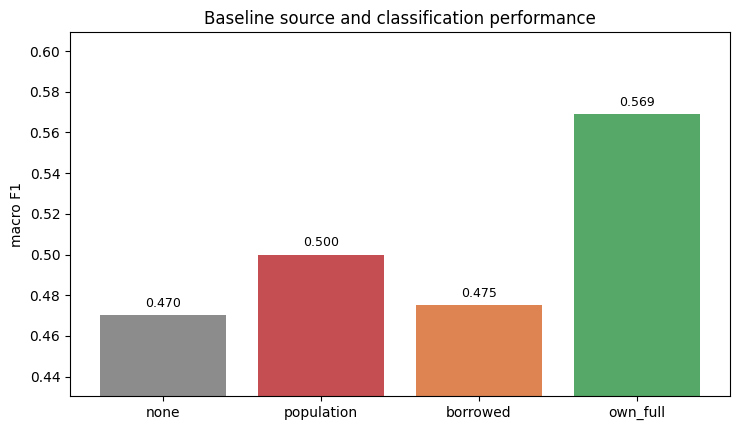

In [9]:
order=['none','population','borrowed','own_full']
print("="*72)
print("EXPERIMENT 1 - WHOSE BASELINE?")
print("="*72)
print(f"{'condition':<14}{'F1':>9}{'kappa':>9}{'MA-MAE':>9}{'distant':>9}   vs own")
print("-"*72)
own=store['own_full']['metrics']['f1']
for k in order:
    if k not in store: continue
    m=store[k]['metrics']
    print(f"{k:<14}{m['f1']:>9.3f}{m['kappa']:>9.3f}{m['ma_mae']:>9.3f}{m['dist']:>9.3f}   {m['f1']-own:+.3f}")
print("="*72)

subs=sorted(int(s) for s in store['own_full']['perfold'])
own_pf=perfold_array(store['own_full']['perfold'],subs)
print("\npaired tests against own baseline:")
for k in ['borrowed','population','none']:
    if k not in store: continue
    arr=perfold_array(store[k]['perfold'],subs)
    try:
        _,p=wilcoxon(arr,own_pf); d=(arr-own_pf).mean()/((arr-own_pf).std(ddof=1)+1e-12)
        verdict='indistinguishable' if p>=0.05 else 'WORSE'
        print(f"  {k:<12} dF1={(arr-own_pf).mean():+.3f}  p={p:.4f}  d={d:+.2f}  {verdict}")
    except Exception as e: print(f"  {k:<12} test skipped ({e})")

print("\nIf 'borrowed' is indistinguishable from 'own', a cold-start protocol")
print("is viable. If clearly worse, the baseline is irreducibly personal --")
print("which is itself a quantitative result worth reporting.")

fig,ax=plt.subplots(figsize=(7.5,4.4))
ks=[k for k in order if k in store]
vals=[store[k]['metrics']['f1'] for k in ks]
bars=ax.bar(ks,vals,color=['#8C8C8C','#C44E52','#DD8452','#55A868'][:len(ks)])
for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2,v+0.004,f"{v:.3f}",ha='center',fontsize=9)
ax.set_ylabel('macro F1'); ax.set_title('Baseline source and classification performance')
ax.set_ylim(min(vals)-0.04,max(vals)+0.04)
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_baseline_transfer.png',dpi=200,bbox_inches='tight'); plt.show()

## 6. Experiment 2 — how much data?

The baseline is fitted on the first N minutes only and applied to the remainder. Evaluation windows
exclude the beats used for fitting, so the two never overlap.

**Bound to state.** Sessions run roughly 90 minutes, so budgets beyond about 45 minutes leave too
little for evaluation. The tested range is limited accordingly, and that ceiling should be reported
rather than extrapolated past.

In [10]:
MINUTES=[2,5,10,20,30,45]
rows=[]
for mins in MINUTES:
    nb_=int(mins*BEATS_PER_MIN)
    short=[s for s,d in wesad.items() if len(d['rr_ms'])<nb_+WINDOW+400]
    if short:
        print(f"{mins:>3} min: skipped (insufficient data for {short})"); continue
    key=f'win_{mins}min'
    if key in store:
        m=store[key]['metrics']; print(f"{mins:>3} min: cached F1={m['f1']:.3f}")
    else:
        fn=lambda sid,rr,ts,k=nb_: own_baseline(rr,ts,upto=k)
        own_baseline.n_fallback=0
        X,y,g=build_with_baseline(fn,eval_from=nb_)      # evaluate AFTER the baseline window
        nfb=own_baseline.n_fallback
        if nfb: print(f"       ({nfb}/15 subjects: Cosinor implausible, used prefix mean)")
        m,pf=run_loso(X,y,g)
        store[key]=dict(metrics=m,perfold=pf,minutes=mins,n_eval=len(y))
        json.dump(store,open(RESULTS,'w'))
        print(f"{mins:>3} min: F1={m['f1']:.3f}  kappa={m['kappa']:.3f}  (n_eval={len(y)})")
    rows.append(dict(minutes=mins,**store[key]['metrics'],n_eval=store[key].get('n_eval',np.nan)))

ws=pd.DataFrame(rows)
print("\n"+"="*66)
print("EXPERIMENT 2 - MINIMUM VIABLE BASELINE WINDOW")
print("="*66)
print(ws.round(3).to_string(index=False))
print("="*66)
print("\nNote: n_eval shrinks as the baseline budget grows, because more of")
print("the session is consumed. Compare F1 with that in mind.")

       (15/15 subjects: Cosinor implausible, used prefix mean)
  2 min: F1=0.473  kappa=0.542  (n_eval=11366)
       (14/15 subjects: Cosinor implausible, used prefix mean)
  5 min: F1=0.453  kappa=0.509  (n_eval=10646)
       (15/15 subjects: Cosinor implausible, used prefix mean)
 10 min: F1=0.470  kappa=0.525  (n_eval=9446)
       (14/15 subjects: Cosinor implausible, used prefix mean)
 20 min: F1=0.483  kappa=0.575  (n_eval=7046)
       (8/15 subjects: Cosinor implausible, used prefix mean)
 30 min: F1=0.469  kappa=0.622  (n_eval=4646)
 45 min: skipped (insufficient data for ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9'])

EXPERIMENT 2 - MINIMUM VIABLE BASELINE WINDOW
 minutes    f1  kappa  ma_mae  dist  n_eval
       2 0.473  0.542   0.799 0.139   11366
       5 0.453  0.509   0.881 0.152   10646
      10 0.470  0.525   0.828 0.156    9446
      20 0.483  0.575   0.761 0.138    7046
      30 0.469  0.622   0.783 0.120    4646

Note: n_eval shrinks as the baseline budget grows, b

full-session baseline F1: 0.569

 minutes       F1   gap to full
       2    0.473        +0.096
       5    0.453        +0.116
      10    0.470        +0.099
      20    0.483        +0.086
      30    0.469        +0.100

no tested budget comes within 0.03 of the full-session baseline


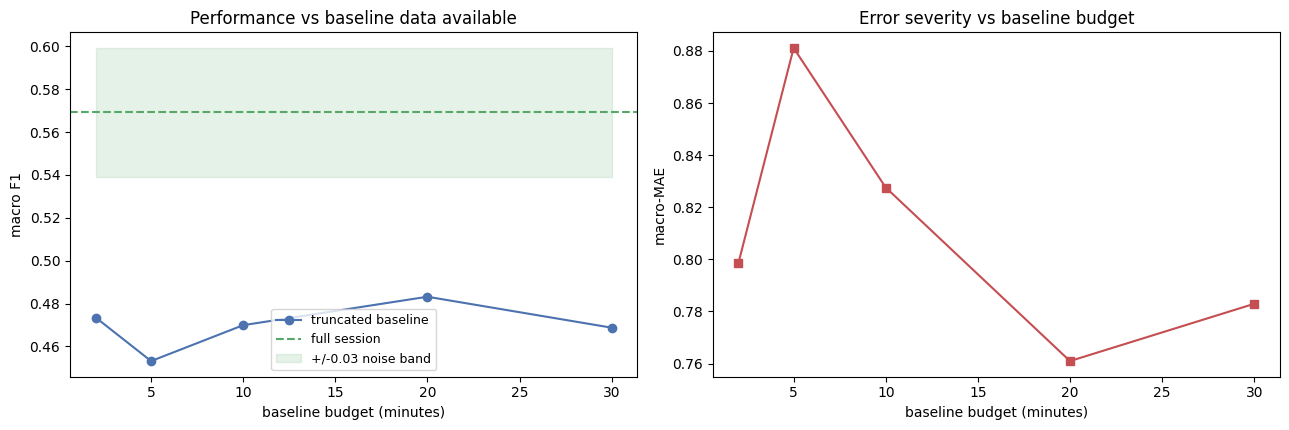

In [11]:
if len(ws)>2:
    full=store['own_full']['metrics']['f1']
    ws['gap_to_full']=full-ws.f1
    print(f"full-session baseline F1: {full:.3f}\n")
    print(f"{'minutes':>8}{'F1':>9}{'gap to full':>14}")
    for _,r in ws.iterrows():
        print(f"{int(r.minutes):>8}{r.f1:>9.3f}{r.gap_to_full:>+14.3f}")

    # first budget within noise of the full-session result
    NOISE=0.03
    ok=ws[ws.gap_to_full.abs()<=NOISE]
    if len(ok):
        print(f"\nfirst budget within {NOISE} of full session: {int(ok.minutes.iloc[0])} minutes")
    else:
        print(f"\nno tested budget comes within {NOISE} of the full-session baseline")

    fig,ax=plt.subplots(1,2,figsize=(13,4.4))
    ax[0].plot(ws.minutes,ws.f1,'o-',color='#4C72B0',label='truncated baseline')
    ax[0].axhline(full,color='#55A868',ls='--',label='full session')
    ax[0].fill_between([ws.minutes.min(),ws.minutes.max()],full-NOISE,full+NOISE,
                       color='#55A868',alpha=.15,label=f'+/-{NOISE} noise band')
    ax[0].set_xlabel('baseline budget (minutes)'); ax[0].set_ylabel('macro F1')
    ax[0].set_title('Performance vs baseline data available'); ax[0].legend(fontsize=9)
    ax[1].plot(ws.minutes,ws.ma_mae,'s-',color='#C44E52')
    ax[1].set_xlabel('baseline budget (minutes)'); ax[1].set_ylabel('macro-MAE')
    ax[1].set_title('Error severity vs baseline budget')
    plt.tight_layout(); plt.savefig(f'{SAVE}/fig_min_window.png',dpi=200,bbox_inches='tight'); plt.show()

## 7. Combining the two results into a protocol

If the borrowed baseline is usable and own-data performance plateaus at some budget, the two combine
into a concrete onboarding specification.

In [12]:
if 'borrowed' in store and len(ws)>2:
    b=store['borrowed']['metrics']['f1']
    crossover=ws[ws.f1>=b]
    print("="*62); print("PROPOSED COLD-START PROTOCOL"); print("="*62)
    print(f"borrowed-baseline F1        : {b:.3f}")
    if len(crossover):
        cm=int(crossover.minutes.iloc[0])
        print(f"own baseline overtakes it at: {cm} minutes")
        print(f"\n  minutes 0-{cm:<3}  use the borrowed cluster baseline")
        print(f"  minute  {cm}+     switch to the user's own baseline")
    else:
        print("own baseline does not overtake the borrowed one within the")
        print("tested range -- the borrowed baseline remains preferable")
        print("throughout, or neither is adequate.")
    print("\nThis is a protocol, not just a measurement: it specifies what a")
    print("deployed system should do for a user it has never seen before.")
else:
    print("run Sections 5 and 6 first")

PROPOSED COLD-START PROTOCOL
borrowed-baseline F1        : 0.475
own baseline overtakes it at: 20 minutes

  minutes 0-20   use the borrowed cluster baseline
  minute  20+     switch to the user's own baseline

This is a protocol, not just a measurement: it specifies what a
deployed system should do for a user it has never seen before.


## 8. Reporting

**Experiment 1.** Report all four conditions together. The interesting quantity is where the borrowed
baseline sits between the population floor and the own-baseline ceiling. State the donor-matching
error (median absolute difference between donor and own level) alongside, since a poor match makes
the borrowed condition a test of the matching procedure rather than of transferability itself.

If the borrowed baseline is statistically indistinguishable from the own baseline, that is a
deployable cold-start result. If it is clearly worse, report it as quantitative evidence that the
baseline is personal — which is consistent with, and strengthens, the existing finding that
class-balanced personal calibration yields +0.082 while naive calibration yields +0.001.

**Experiment 2 — a numerical caveat.** At very short budgets the Cosinor parameters are
unidentifiable and the extrapolated baseline can diverge to physiologically impossible values. Such
fits fall back to the prefix mean, and the number of subjects affected is printed per budget. Report
that count: a short-budget result driven mostly by fallbacks is a statement about fit stability, not
about baseline quality.

**Experiment 2.** Report the curve, not a single number, and state the session-length ceiling
explicitly: budgets beyond roughly 45 minutes cannot be tested on 90-minute recordings, so no claim
should be made about them. Note also that the evaluation set shrinks as the budget grows, which
works against larger budgets and should be acknowledged when reading the curve.

**The combined protocol.** Only state a switchover point if the crossover is clear. If the two curves
sit within run-to-run noise of each other, the honest conclusion is that the choice does not matter
much — which is still useful guidance for a deployment.

**What neither experiment changes.** The mechanism finding, the reported model performance, and the
existing limitations all stand. These address a deployment question the project had previously listed
as unresolved.
